In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc

iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.conf_af3.parquet"
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)

iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

iedb_II_pmhc = pl.read_parquet(
    "../../data/iedb_II/pmhc/staged/iedb_II_pmhc.conf_af3.parquet"
)

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)

class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

_, iedb_II_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(iedb_II.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

iedb_II = iedb_II.with_columns(pl.Series(name="p_dgeom", values=iedb_II_p_dgeom))

(<Figure size 750x500 with 1 Axes>,
 <Axes: xlabel='tcr_ref_count bin', ylabel='iptm'>)

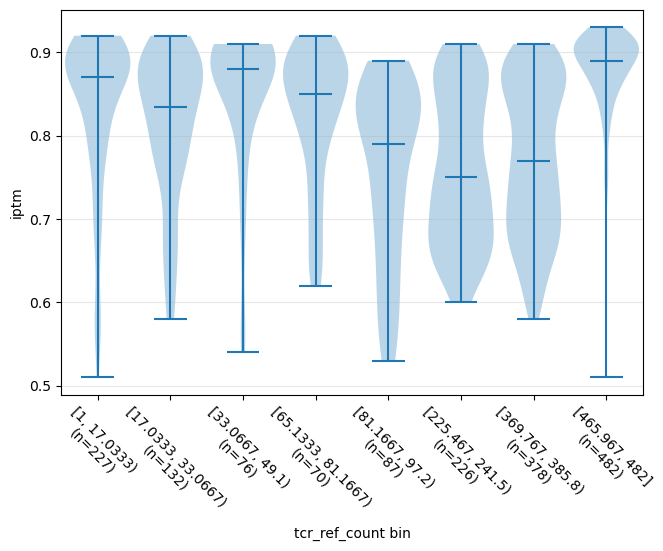

In [2]:
from tcrtrifold.utils import FORMAT_TCR_COLS
import numpy as np
import matplotlib.pyplot as plt


def binned_violinplot(
    tcr_ref_count, feat_val, bins=10, bin_edges=None, feat_label="feature value"
):
    """
    Parameters
    ----------
    tcr_ref_count : array-like
        Reference counts per item (binned on x-axis).
    feat_val : array-like
        Feature values per item (violin-distributed on y-axis).
    bins : int, optional
        If bin_edges is None, use this many equal-width bins (default 10).
    bin_edges : array-like, optional
        Explicit bin edges. If provided, 'bins' is ignored. Example: [0, 5, 10, 25, 50, np.inf]
    feat_label : str, optional
        Y-axis label.

    Returns
    -------
    fig, ax : Matplotlib Figure and Axes
    """
    x = np.asarray(tcr_ref_count, dtype=float)
    y = np.asarray(feat_val, dtype=float)

    if bin_edges is None:
        edges = np.histogram_bin_edges(x, bins=bins)
    else:
        edges = np.asarray(bin_edges, dtype=float)

    groups = []
    labels = []
    counts = []

    for i in range(len(edges) - 1):
        left, right = edges[i], edges[i + 1]
        # include right edge only for the last bin
        if i == len(edges) - 2:
            mask = (x >= left) & (x <= right)
            lab = f"[{left:g}, {right:g}]"
        else:
            mask = (x >= left) & (x < right)
            lab = f"[{left:g}, {right:g})"

        vals = y[mask]
        if vals.size == 0:
            continue  # skip empty bins
        groups.append(vals)
        labels.append(lab)
        counts.append(vals.size)

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    parts = ax.violinplot(
        groups,
        positions=np.arange(len(groups)),
        showmeans=False,
        showmedians=True,
        widths=0.9,
    )

    # X labels include bin range and count per bin
    xtick_labels = [f"{lab}\n(n={n})" for lab, n in zip(labels, counts)]
    ax.set_xticks(np.arange(len(groups)), xtick_labels, rotation=-45)
    ax.set_xlim(-0.5, len(groups) - 0.5)
    ax.set_ylabel(feat_label)
    ax.set_xlabel("tcr_ref_count bin")
    # ax.set_title()
    ax.grid(axis="y", alpha=0.3)

    # Optional: tighten y-limits a bit
    y_all = np.concatenate(groups) if groups else np.array([0.0])
    y_pad = 0.05 * (np.nanmax(y_all) - np.nanmin(y_all) + 1e-9)
    ax.set_ylim(np.nanmin(y_all) - y_pad, np.nanmax(y_all) + y_pad)

    return fig, ax


expl_ref = iedb_II.filter(pl.col("cognate")).explode("references")
tcr_to_chain = expl_ref.select(FORMAT_TCR_COLS + ["references"]).unique()
tcr_ref_count = expl_ref.group_by("references").len(name="num_tcrs")

expl_ref = expl_ref.join(tcr_ref_count, on="references", how="inner")

binned_violinplot(
    expl_ref.select("num_tcrs").to_series().to_numpy(),
    expl_ref.select("iptm").to_series().to_numpy(),
    bins=30,
    feat_label="iptm",
    # bin_edges=[0, 2, 11, 101, np.inf],
)

In [3]:
bad_ref = (
    expl_ref.filter(pl.col("num_tcrs") > 80, pl.col("num_tcrs") < 385)
    .select("references")
    .unique()
)

bad_ref_tcr = bad_ref.join(tcr_to_chain, on="references")

bad_ref_antigen = (
    expl_ref.join(bad_ref, on="references").select(FORMAT_ANTIGEN_COLS).unique()
)

# bad references uniquely contribute these antigens
expl_ref.join(bad_ref_antigen, on=FORMAT_ANTIGEN_COLS).select("references").unique()

references
str
"""1040829"""
"""1040295"""
"""1041160"""


In [9]:
expl_ref.join(bad_ref_antigen, on=FORMAT_ANTIGEN_COLS).select(["peptide", "mhc_2_name"]  + ["references"]).unique().write_csv("/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/tmp/fat_antigens.csv")

In [32]:
bad_ref_antigen.select("peptide", "mhc_2_name")

peptide,mhc_2_name
str,str
"""SLFFSAQPFEITAST""","""DRB1*07:01"""
"""TFEYVSQPFLMDLE""","""DPB1*04:01"""


peptide,mean_p_mhc_pae
str,f64
"""SLFFSAQPFEITAST""",9.315844
"""TFEYVSQPFLMDLE""",8.03952


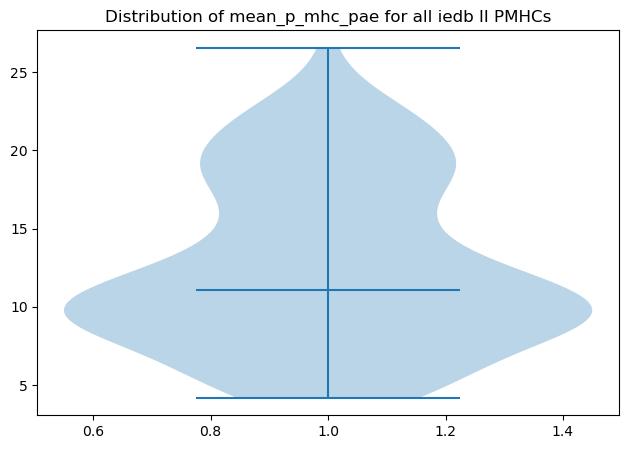

In [33]:
arr = iedb_II_pmhc.select("mean_p_mhc_pae").to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 5.0))
parts = ax.violinplot(
    arr,
    # positions=np.arange(len(groups)),
    showmeans=False,
    showmedians=True,
    widths=0.9,
)

ax.set_title("Distribution of mean_p_mhc_pae for all iedb II PMHCs")

bad_ref_antigen.join(iedb_II_pmhc, on=FORMAT_ANTIGEN_COLS).select(
    "peptide", "mean_p_mhc_pae"
)

In [5]:
tcr_ref_count.sort(by="num_tcrs", descending=True)

references,num_tcrs
str,u32
"""1041206""",482
"""1040295""",378
"""1040829""",226
"""1041160""",87
"""1038538""",70
…,…
"""1033341""",1
"""1038518""",1
"""365""",1


In [6]:
iedb_II_cleaner = filter_to_cog_thresh(
    iedb_II.join(bad_ref_antigen, on=FORMAT_ANTIGEN_COLS, how="anti"), 20
)

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

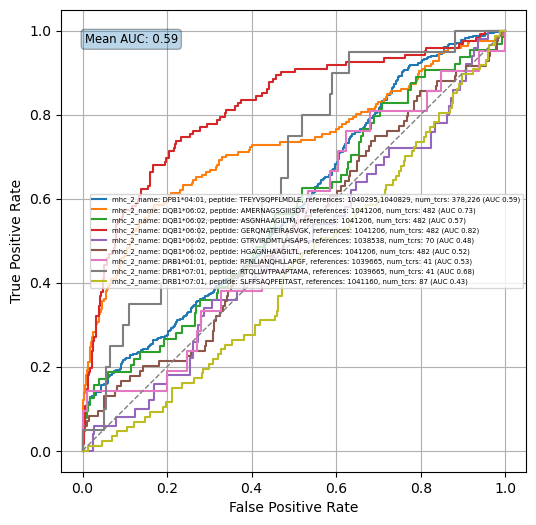

In [7]:
from tcrtrifold.viz_utils import plot_auc_per_antigen

iedb_II_filt = filter_to_cog_thresh(iedb_II, 20)

iedb_II_auc = antigen_raw_score_auc(
    iedb_II_filt.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

iedb_II_auc = iedb_II_auc.join(
    expl_ref.group_by(FORMAT_ANTIGEN_COLS)
    .agg(
        pl.col("references").unique(maintain_order=True),
        pl.col("num_tcrs").unique(maintain_order=True),
    )
    .with_columns(
        pl.col("references").list.join(","),
        pl.col("num_tcrs").cast(pl.List(pl.String)).list.join(","),
    ),
    on=FORMAT_ANTIGEN_COLS,
)

plot_auc_per_antigen(
    iedb_II_auc, id_cols=["mhc_2_name", "peptide", "references", "num_tcrs"]
)

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

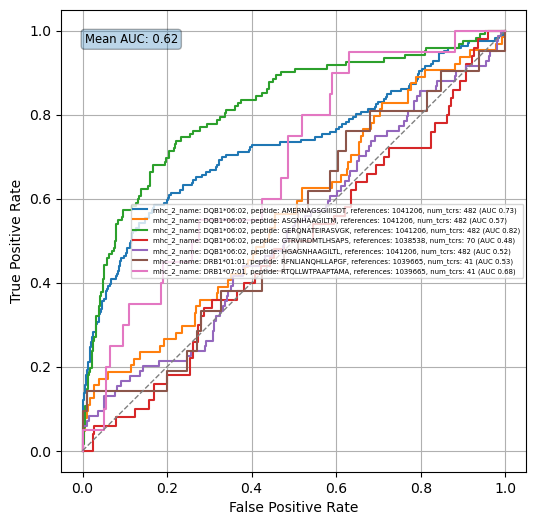

In [8]:
from tcrtrifold.viz_utils import plot_auc_per_antigen

iedb_II_auc = antigen_raw_score_auc(
    iedb_II_cleaner.with_columns(
        (1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")
    ),
    "mean_p_tcr_pae",
)

iedb_II_auc = iedb_II_auc.join(
    expl_ref.group_by(FORMAT_ANTIGEN_COLS)
    .agg(
        pl.col("references").unique(maintain_order=True),
        pl.col("num_tcrs").unique(maintain_order=True),
    )
    .with_columns(
        pl.col("references").list.join(","),
        pl.col("num_tcrs").cast(pl.List(pl.String)).list.join(","),
    ),
    on=FORMAT_ANTIGEN_COLS,
)

plot_auc_per_antigen(
    iedb_II_auc, id_cols=["mhc_2_name", "peptide", "references", "num_tcrs"]
)

In [9]:
iedb_II_auc.select("peptide").unique().sort(by="peptide").to_series().to_list()

['AMERNAGSGIIISDT',
 'ASGNHAAGILTM',
 'GERQNATEIRASVGK',
 'GTRVIRDMTLHSAPS',
 'HGAGNHAAGILTL',
 'RFNLIANQHLLAPGF',
 'RTQLLWTPAAPTAMA']

In [10]:
redundant_tcr = (
    iedb_II_cleaner.filter(
        pl.col("peptide").is_in(
            ["AMERNAGSGIIISDT", "ASGNHAAGILTM", "GERQNATEIRASVGK", "HGAGNHAAGILTL"]
        ),
        pl.col("cognate"),
    )
    .group_by(FORMAT_TCR_COLS)
    .agg(pl.col("peptide").len())
    .filter(pl.col("peptide") > 1)
).select(pl.exclude("peptide"))

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

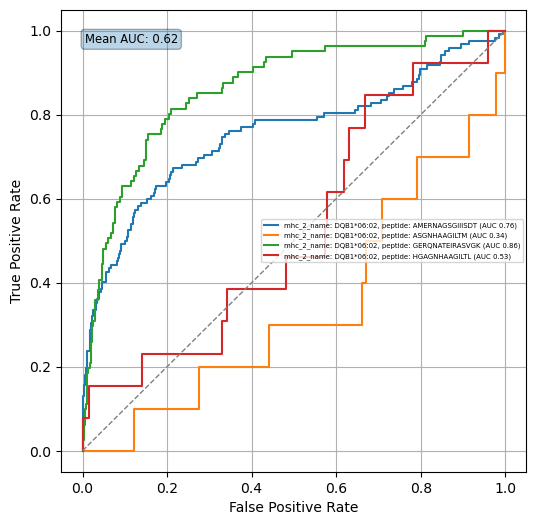

In [11]:
iedb_II_bigstudy = iedb_II_cleaner.filter(
    pl.col("peptide").is_in(
        ["AMERNAGSGIIISDT", "ASGNHAAGILTM", "GERQNATEIRASVGK", "HGAGNHAAGILTL"]
    ),
).join(redundant_tcr, on=FORMAT_TCR_COLS, how="anti")

bigstudy_auc = antigen_raw_score_auc(
    iedb_II_bigstudy.with_columns(
        (1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")
    ),
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(bigstudy_auc, id_cols=["mhc_2_name", "peptide"])

In [ ]:
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import numpy as np


def violin_abs_feature(df, featname: str, invert=False):
    """
    Violin plot of |feature| for cognates vs noncognates.
    Annotates:
      - absolute feature threshold T above which no noncognates are found
      - # and % of cognates with |feature| > T
    """
    # Pull data from Polars or Pandas
    if hasattr(df, "select"):  # Polars
        dat = df.select([featname, "cognate"]).to_numpy()
    else:  # Pandas/DataFrame-like
        dat = df[[featname, "cognate"]].to_numpy()

    x = dat[:, 0].astype(float)
    y = dat[:, 1].astype(bool)  # True = cognate

    # Drop NaNs / infs in the feature
    finite = np.isfinite(x)
    x = x[finite]
    y = y[finite]

    x_abs = np.abs(x)
    cog_vals = x_abs[y]
    non_vals = x_abs[~y]

    # Threshold T: "absolute feature value above which no noncognates are found"
    if non_vals.size > 0:
        if invert:
            T = float(np.min(non_vals))
        else:
            T = float(np.max(non_vals))
    else:
        T = np.nan  # no noncognates present; threshold undefined

    # Cognate counts above threshold
    if np.isfinite(T) and cog_vals.size > 0:
        if invert:
            n_cog_above = int(np.sum(cog_vals < T))
        else:
            n_cog_above = int(np.sum(cog_vals > T))
        n_cog_total = int(cog_vals.size)
        pct_cog_above = (n_cog_above / n_cog_total) * 100.0
    else:
        n_cog_above = 0
        n_cog_total = int(cog_vals.size)
        pct_cog_above = np.nan

    fig, ax = plt.subplots(figsize=(6, 6))

    parts = ax.violinplot(
        [non_vals, cog_vals],
        positions=[0, 1],
        showmeans=False,
        showmedians=True,
        widths=0.8,
    )

    # Basic cosmetics
    ax.set_xticks([0, 1], labels=["noncognate", "cognate"])
    ax.set_ylabel(f"{featname}")
    ax.set_title(f"Distribution of {featname}")

    # Horizontal line at T
    if np.isfinite(T):
        ax.axhline(T, linestyle="--", linewidth=1, alpha=0.8)
        ax.text(
            0.02,
            0.98,
            f"Threshold feature value = {T:.3g}\n"
            f"Cognates > T: {n_cog_above}/{n_cog_total}"
            + (f" ({pct_cog_above:.1f}%)" if np.isfinite(pct_cog_above) else ""),
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize="small",
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.25),
        )

    # Expand y-limits a bit to show the annotation line clearly
    ymin, ymax = ax.get_ylim()
    if np.isfinite(T):
        ymax = max(ymax, T * 1.05 if T > 0 else 1.0)
    ax.set_ylim(ymin, ymax)

    return fig, ax

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,receptor_id,references,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,…,mean_tcr_pmhc_interface_pae,mean_p_tcr_interface_contact_prob,mean_tcr_pmhc_interface_contact_prob,mean_p_tcr_pae,mean_tcr_p_pae,mean_mhc_tcr_pae,mean_tcr_mhc_pae,tcr_mhc_contacts,peptide_tcr_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_p_tcr_pae_II,mean_tcr_p_pae_II,mean_mhc_tcr_pae_II,mean_tcr_mhc_pae_II,peptide_mean_pLDDT_II,pred_dgeom_4,d,mhc_unit_x_is_negative,mhc_unit_y,mhc_unit_z,tcr_unit_x_is_negative,tcr_unit_y,tcr_unit_z,torsion,p_dgeom
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],list[str],bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,struct[8],f64,bool,f64,f64,bool,f64,f64,f64,f64
"""0007d377934b075588b311883f901e…",true,"""AMERNAGSGIIISDT""","""II""","""alpha""","""human""","""DQA1*01:02""","""EDIVADHVASCGVNLYQFYGPSGQYTHEFD…","""beta""","""human""","""DQB1*06:02""","""RDSPEDFVFQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""SQQGEEDPQALSIQEGENATMNCSYKTSIN…","""beta""","""human""","""DGGITQSPKYLFRKEGQNVTLSCEQNLNHD…","""TSINN""","""IRSNERE""","""DTSKKS""","""CATGHTGANSKLTF""","""LNHDA""","""SQIVND""","""EKKES""","""CASSLQGTPNGNQPQHF""","[""213484""]","[""1041206""]",false,"[0.76, 0.84, … 0.8]","[[0.02, 0.84, … 0.69], [0.84, 0.88, … 0.83], … [0.69, 0.83, … 0.88]]","[[0.76, 1.43, … 2.39], [1.53, 0.76, … 1.36], … [1.93, 1.58, … 0.76]]","[0.02, 0.88, … 0.88]",0.08,0.0,0.89,0.9,…,5.730472,0.04772,0.013885,10.5223,6.679916,7.76,9.092689,13,20,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 1.0], … [0.0, 0.0, … 0.0]]",77.887641,84.197568,87.175968,90.663778,81.265258,91.57718,88.704565,91.264762,84.013548,86.149471,91.2275,10.497334,0.073385,0.062767,7.76,9.092689,0.162054,"{28.881308,false,0.186764,0.079844,false,-0.002969,0.036507,3.360972}",28.881308,false,0.186764,0.079844,false,-0.002969,0.036507,3.360972,0.967108
"""01064f676df70d7eaf41fd7e034dfe…",true,"""GERQNATEIRASVGK""","""II""","""alpha""","""human""","""DQA1*01:02""","""EDIVADHVASCGVNLYQFYGPSGQYTHEFD…","""beta""","""human""","""DQB1*06:02""","""RDSPEDFVFQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""QKEVEQNSGPLSVPEGAIASLNCTYSDRGS…","""beta""","""human""","""NAGVTQTPKFQVLKTGQSMTLQCAQDMNHN…","""DRGSQS""","""IYSNGD""","""NKASQY""","""CAVNYLGQNFVF""","""MNHNS""","""SASEGT""","""LNKRE""","""CASSEGTSYGYTF""","[""213371""]","[""1041206""]",false,"[0.84, 0.89, … 0.83]","[[0.03, 0.9, … 0.75], [0.9, 0.89, … 0.87], … [0.75, 0.87, … 0.89]]","[[0.76, 0.84, … 1.31], [0.82, 0.76, … 1.24], … [1.49, 1.61, … 0.76]]","[0.03, 0.89, … 0.89]",0.08,0.0,0.92,0.92,…,3.224847,0.043139,0.010795,8.448277,4.626333,7.039656,7.032643,35,13,"[[0.0, 0.0, … 0.0], [0.0, 2.0, … 5.0], … [0.0, 0.0, … 0.0]]",86.441416,90.8075,95.324566,92.059592,94.335729,92.15025,90.205676,89.434445,95.031053,92.972854,94.308341,8.640935,0.048168,0.043205,7.039656,7.032643,0.067267,"{28.224104,false,0.09781,-0.028052,false,-0.072536,0.032163,3.477817}",28.224104,false,0.09781,-0.028052,false,-0.072536,0.032163,3.477817,0.754908
"""011f769f41411e5f5bdecad887dd27…",true,"""AMERNAGSGIIISDT""","""II""","""alpha""","""human""","""DQA1*01:02""","""EDIVADHVASCGVNLYQFYGPSGQYTHEFD…","""beta""","""human""","""DQB1*06:02""","""RDSPEDFVFQFKGMCYFT

In [43]:
big_ref_ant.select("peptide").unique()

peptide
str
"""GERQNATEIRASVGK"""
"""ASGNHAAGILTM"""
"""AMERNAGSGIIISDT"""
"""HGAGNHAAGILTL"""


In [47]:
iedb_II.filter(pl.col("references").list.contains("1041206")).select(
    FORMAT_ANTIGEN_COLS
).unique().to_series().to_list()

['RSALILRGSVAHKSC',
 'QASGNHAAGILTM',
 'GERQDATEIRASVGR',
 'HGAGNHAAGILTL',
 'ASGNHAAGILTM',
 'AMERNAGSGIIISDT',
 'LRLATGLRNIPSIQS',
 'LHGAGNHAAGILTL',
 'RSGPPGLQGRLQRLLQASGNHAAGILTM',
 'LQASGNHAAGILTM',
 'GAGNHAAGILTL',
 'GNHAAGILTLGKRRS',
 'TYNAELLVLLENERT',
 'LHGAGNHAAGILTLG',
 'GERQNATEIRASVGK']

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of mean_p_tcr_pae'}, ylabel='mean_p_tcr_pae'>)

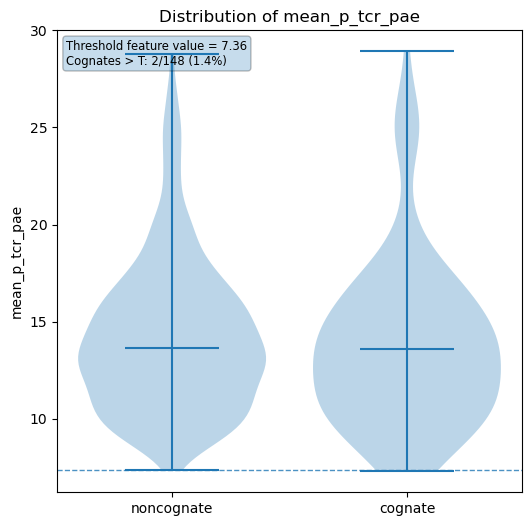

In [60]:
big_ref_ant = (
    iedb_II_filt.filter(pl.col("references").list.contains("1041206"))
    .select(FORMAT_ANTIGEN_COLS)
    .unique()
).filter(pl.col("peptide").is_in(["ASGNHAAGILTM", "HGAGNHAAGILTL"]))

big_ref_triad = iedb_II.join(
    big_ref_ant,
    on=FORMAT_ANTIGEN_COLS,
)

violin_abs_feature(big_ref_triad, "mean_p_tcr_pae", invert=True)

In [61]:
big_ref_ant.join(iedb_II_pmhc, on=FORMAT_ANTIGEN_COLS).select(
    "peptide", "iptm"
)

peptide,iptm
str,f64
"""HGAGNHAAGILTL""",0.91
"""ASGNHAAGILTM""",0.92


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of mean_p_tcr_pae'}, ylabel='mean_p_tcr_pae'>)

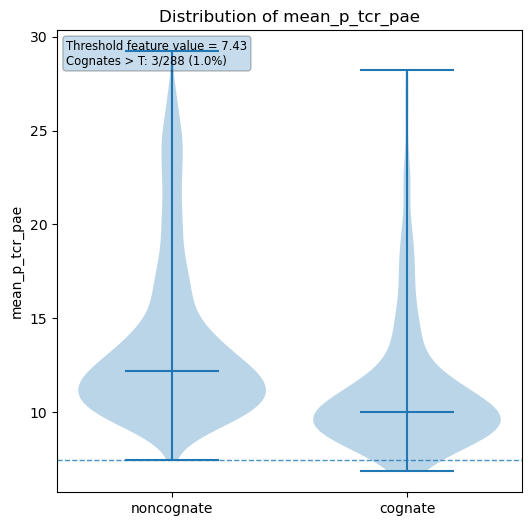

In [57]:
big_ref_ant = (
    iedb_II_filt.filter(pl.col("references").list.contains("1041206"))
    .select(FORMAT_ANTIGEN_COLS)
    .unique()
).filter(~pl.col("peptide").is_in(["ASGNHAAGILTM", "HGAGNHAAGILTL"]))

big_ref_triad = iedb_II.join(
    big_ref_ant,
    on=FORMAT_ANTIGEN_COLS,
)

violin_abs_feature(big_ref_triad, "mean_p_tcr_pae", invert=True)

In [58]:
big_ref_ant.join(iedb_II_pmhc, on=FORMAT_ANTIGEN_COLS).select(
    "peptide", "mean_p_mhc_pae"
)

peptide,mean_p_mhc_pae
str,f64
"""GERQNATEIRASVGK""",8.517712
"""AMERNAGSGIIISDT""",10.92219


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of iptm'}, ylabel='iptm'>)

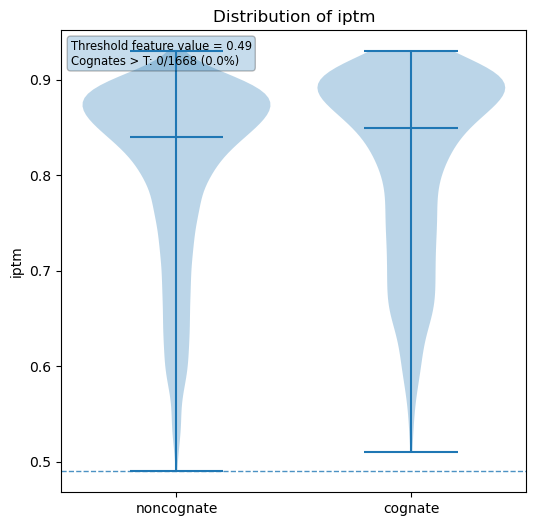

In [40]:
violin_abs_feature(iedb_II, "iptm", invert=True)